# 03 - Deep Learning Models for Multivariate Financial Time Series

## Description

This notebook implements and compares deep learning models for multivariate financial time series prediction.

The objective is to evaluate how different groups of financial variables impact predictive performance. The models are trained using sliding windows over time series data.

Three input configurations are evaluated:
- Traditional financial indicators
- Cryptocurrency indicators
- Combined features

Models implemented:
- LSTM
- GRU
- 1D CNN

Evaluation is performed using regression metrics such as MAE and RMSE.

# 1. Imports

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.benchmark = True



Using device: cuda


In [171]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# 2. Load data

In [172]:
df = pd.read_csv("../data/generated/processed_full.csv")
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

# ===== Lags =====
for lag in range(1, 6):
    df[f"btc_lag{lag}"] = df["btc_return"].shift(lag)

# ===== MOMENTUM =====
df["btc_momentum_5"] = df["btc_return"].rolling(5).mean()

# ===== Volatility  =====
df["btc_vol_10"] = df["btc_return"].rolling(10).std()

# ===== Clean =====
df = df.dropna().reset_index(drop=True)

# 3. Feature sets

In [173]:
FEATURE_SETS = {
    "btc_only": [
        "btc_return",
        "btc_lag1", "btc_lag2", "btc_lag3", "btc_lag4", "btc_lag5",
        "btc_momentum_5",
        "btc_vol_10"
    ],
    "crypto": [
        "eth_return", "bnb_return", "xrp_return"
    ],
    "combined": [
        "btc_return",
        "btc_lag1", "btc_lag2", "btc_lag3",
        "btc_momentum_5",
        "btc_vol_10",
        "eth_return", "bnb_return", "xrp_return"
    ]
}

# 4. Target

In [174]:
TARGET = "btc_return"

# 5. Sliding Window

In [175]:
def create_sequences(data, target, window_size=30):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(target[i+window_size])

    return np.array(X), np.array(y)

# 6. Train/Test Split

In [176]:
split_ratio = 0.8
split_index = int(len(df) * split_ratio)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# 7. Scaling

In [177]:
def scale_data(train, test):
    scaler = StandardScaler()

    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    return train_scaled, test_scaled

# 8. Dataset class

In [178]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 9. MODELOS

LSTM

In [179]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        return self.fc(hidden[-1])

LSTM + Attention

In [180]:
class LSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        # Attention
        self.attn = nn.Linear(hidden_size, 1)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, seq, features)
        lstm_out, _ = self.lstm(x)  
        # (batch, seq, hidden)

        # Attention scores
        attn_weights = torch.softmax(self.attn(lstm_out), dim=1)
        # (batch, seq, 1)

        # Weighted sum
        context = torch.sum(attn_weights * lstm_out, dim=1)
        # (batch, hidden)

        return self.fc(context)

GRU

In [181]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.gru = nn.GRU(
            input_size,
            hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        _, hidden = self.gru(x)
        return self.fc(hidden[-1])

1D CNN

In [182]:
class CNNModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_size, 32, kernel_size=3, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Conv1d(32, 32, kernel_size=3, padding=2, dilation=2),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.AdaptiveAvgPool1d(1)
        )

        self.fc = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.squeeze(-1)
        return self.fc(x)

# 10. Training function

In [183]:
def train_model(model, loader, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch).squeeze()
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


# 11. Evaluation

In [184]:

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        with torch.no_grad():
            preds = model(X_test_tensor).squeeze().cpu().numpy()
            
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return mae, rmse

# 12. Principal Loop

In [185]:
PARAM_GRID = {
    "epochs": [5, 10, 20],
    "window_size": [3, 7],
    "hidden_size": [32, 64, 128, 256],
    "lr": [ 0.001, 0.0005]
}
BATCH_SIZES = [8, 16, 32]

In [186]:

import itertools

keys = PARAM_GRID.keys()
values = PARAM_GRID.values()

experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

print("Total experiments:", len(experiments) * len(BATCH_SIZES))

Total experiments: 144


In [187]:

all_results = []
start = time.time()
for config_name, features in FEATURE_SETS.items():
    for exp in experiments:
        print(f"\nRunning: {config_name} | {exp}")
        # params
        window_size = exp["window_size"]
        epochs = exp["epochs"]
        hidden_size = exp["hidden_size"]
        lr = exp["lr"]
        # data
        train_features = train_df[features]
        test_features = test_df[features]
        train_scaled, test_scaled = scale_data(train_features, test_features)
        X_train, y_train = create_sequences(train_scaled, train_df[TARGET].values, window_size)
        X_test, y_test = create_sequences(test_scaled, test_df[TARGET].values, window_size)
        train_dataset = TimeSeriesDataset(X_train, y_train)
        input_size = len(features)
        for batch_size in BATCH_SIZES:
            train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=False
            )
            models = {
            "LSTM": LSTMModel(input_size, hidden_size).to(device),
            "LSTM_Attn": LSTMAttention(input_size, hidden_size).to(device),
            "GRU": GRUModel(input_size, hidden_size).to(device),
            "CNN": CNNModel(input_size).to(device)
            }
            for model_name, model in models.items():
                train_model(model, train_loader, epochs=epochs, lr=lr)
                mae, rmse = evaluate_model(model, X_test, y_test)
                result = {
                "config": config_name,
                "model": model_name,
                "mae": mae,
                "rmse": rmse,
                "epochs": epochs,
                "window": window_size,
                "hidden_size": hidden_size,
                "lr": lr,
                "batch_size": batch_size
                }
                all_results.append(result)
                pd.DataFrame(all_results).to_csv("experiments_results.csv", index=False)
                
elapsed = time.time() - start
print(f"\nTotal time: {elapsed/60:.2f} minutes")


Running: btc_only | {'epochs': 5, 'window_size': 3, 'hidden_size': 32, 'lr': 0.001}
Epoch 1, Loss: 3.7298
Epoch 2, Loss: 3.3069
Epoch 3, Loss: 3.2620
Epoch 4, Loss: 3.2201
Epoch 5, Loss: 3.2164
Epoch 1, Loss: 5.1829
Epoch 2, Loss: 3.5580
Epoch 3, Loss: 3.4222
Epoch 4, Loss: 3.2504
Epoch 5, Loss: 3.2936
Epoch 1, Loss: 4.2638
Epoch 2, Loss: 3.6787
Epoch 3, Loss: 3.5031
Epoch 4, Loss: 3.4477
Epoch 5, Loss: 3.3408
Epoch 1, Loss: 8.3033
Epoch 2, Loss: 4.9838
Epoch 3, Loss: 4.0202
Epoch 4, Loss: 3.3720
Epoch 5, Loss: 3.1707
Epoch 1, Loss: 2.0524
Epoch 2, Loss: 1.6784
Epoch 3, Loss: 1.6389
Epoch 4, Loss: 1.6128
Epoch 5, Loss: 1.6165
Epoch 1, Loss: 2.2357
Epoch 2, Loss: 1.7858
Epoch 3, Loss: 1.7248
Epoch 4, Loss: 1.6862
Epoch 5, Loss: 1.6590
Epoch 1, Loss: 1.9696
Epoch 2, Loss: 1.8589
Epoch 3, Loss: 1.7745
Epoch 4, Loss: 1.7014
Epoch 5, Loss: 1.7064
Epoch 1, Loss: 3.0445
Epoch 2, Loss: 2.0434
Epoch 3, Loss: 1.7316
Epoch 4, Loss: 1.6678
Epoch 5, Loss: 1.5311
Epoch 1, Loss: 1.2450
Epoch 2, Loss

# 13. Results

In [188]:
df_results = pd.read_csv("experiments_results.csv")

df_results.sort_values("mae").head(20)



,config,model,mae,rmse,epochs,window,hidden_size,lr,batch_size
1374,combined,GRU,0.036776,0.051140,10,3,64,0.0010,16
1238,combined,GRU,0.036794,0.051156,5,3,256,0.0005,8
840,crypto,LSTM,0.036874,0.051252,10,3,256,0.0010,8
1420,combined,LSTM,0.037100,0.051912,10,3,256,0.0010,16
1394,combined,GRU,0.037116,0.051743,10,3,128,0.0010,8
1382,combined,GRU,0.037153,0.051729,10,3,64,0.0005,8
1424,combined,LSTM,0.037159,0.051822,10,3,256,0.0010,32
1620,combined,LSTM,0.037176,0.051886,20,3,256,0.0005,8
1624,combined,LSTM,0.037186,0.052198,20,3,256,0.0005,16
1392,combined,LSTM,0.037206,0.051506,10,3,128,0.0010,8


In [189]:
summary_model = df_results.groupby("model")["mae"].agg(["mean", "std", "min"]).sort_values("mean", ascending=True)
summary_config = df_results.groupby("config")["mae"].agg(["mean", "std", "min"]).sort_values("mean", ascending=True)
summary_window = df_results.groupby("window")["mae"].agg(["mean", "std", "min"]).sort_values("mean", ascending=True)

print(summary_model)
print(summary_config)
print(summary_window)

               mean       std       min
model                                  
LSTM       0.038542  0.000582  0.036874
GRU        0.038595  0.000717  0.036776
LSTM_Attn  0.038644  0.000563  0.037288
CNN        0.049401  0.010839  0.037968
              mean       std       min
config                                
btc_only  0.040101  0.003660  0.037332
combined  0.041096  0.005903  0.036776
crypto    0.042690  0.010154  0.036874
            mean       std       min
window                              
3       0.040392  0.005203  0.036776
7       0.042199  0.008626  0.037792


# 14. Visualization

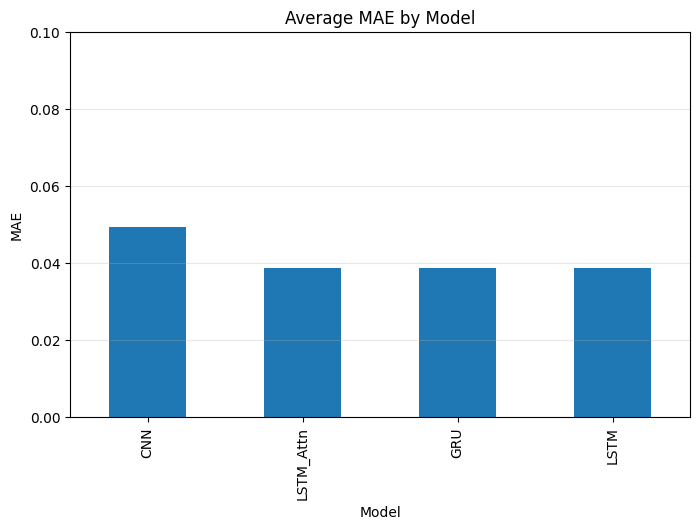

In [190]:
model_avg = df_results.groupby("model")["mae"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
model_avg.plot(kind="bar")
plt.title("Average MAE by Model")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.ylim(0, .1)
plt.grid(axis="y", alpha=0.3)
plt.show()

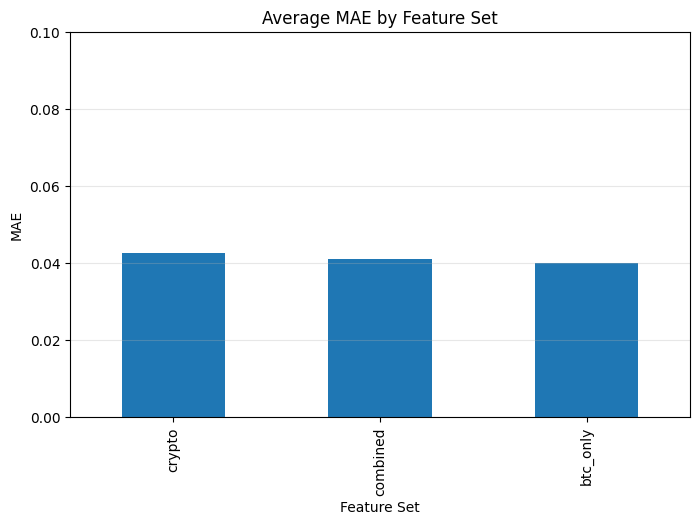

In [194]:
config_avg = df_results.groupby("config")["mae"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
config_avg.plot(kind="bar")
plt.title("Average MAE by Feature Set")
plt.ylabel("MAE")
plt.xlabel("Feature Set")
plt.ylim(0, .1)
plt.grid(axis="y", alpha=0.3)
plt.show()

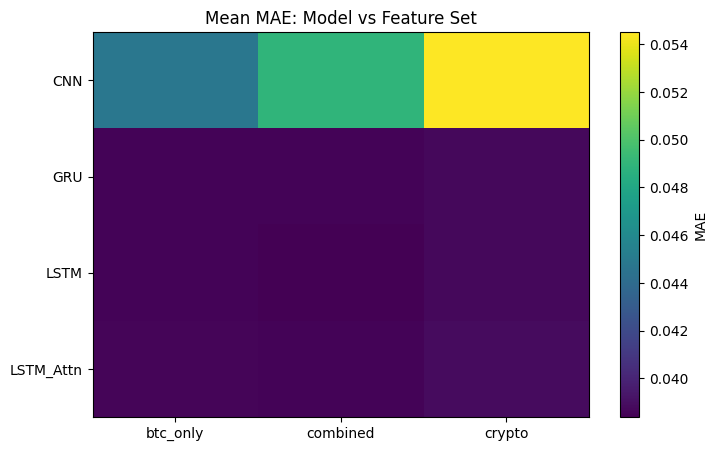

In [192]:

pivot = df_results.pivot_table(
    values="mae",
    index="model",
    columns="config",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="MAE")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Mean MAE: Model vs Feature Set")
plt.show()

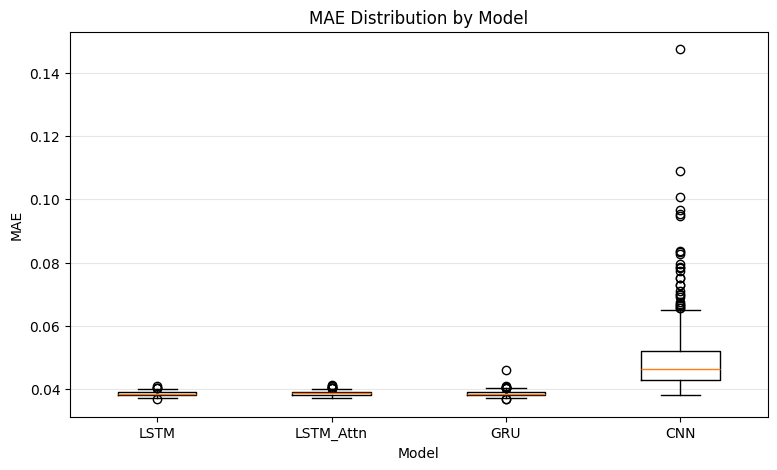

In [193]:
models = df_results["model"].unique()

data = [df_results[df_results["model"] == m]["mae"] for m in models]

plt.figure(figsize=(9,5))
plt.boxplot(data, tick_labels=models)
plt.title("MAE Distribution by Model")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.grid(axis="y", alpha=0.3)
plt.show()